In [ ]:

class GCNModel(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCNModel, self).__init__()
        self.conv1 = GCNConv(4, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels * 2)
        self.conv3 = GCNConv(hidden_channels * 2, hidden_channels)
        self.fc_defect = torch.nn.Linear(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(p=0.5)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.fc_defect(x)

# Define model, optimizer, and scheduler
model = GCNModel(hidden_channels=64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)

# Training loop
for epoch in range(1, 201):
    train_loss = train(train_loader)
    val_loss = test(val_loader)
    scheduler.step()  # Adjust the learning rate
    print(f'Epoch {epoch}, Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}')



Defect-free data occurrences in train_pairs: 8 (expected: 8)
Defect-free data occurrences in val_pairs: 1 (expected: 1)
Defect-free data occurrences in test_pairs: 1 (expected: 1)

All defect-free data pairs are correctly added.
Training data size: 3
Validation data size: 3
Test data size: 3
欠陥なしデータがトレーニングデータに含まれていません。
Training data: Data(x=[4384800, 4], edge_index=[2, 7124], y=[4384800])
Validation data: Data(x=[767340, 4], edge_index=[2, 7124], y=[767340])
Test data: Data(x=[767340, 4], edge_index=[2, 7124], y=[767340])

--- Training ---
data: Normalized1_Defect4x4_ELNOD_L14B34.npy, label: DefectLabel_L14B34.npy
data: Normalized1_Defect4x4_ELNOD_L7B34.npy, label: DefectLabel_L7B34.npy

--- Validation ---
data: Normalized1_Defect4x4_ELNOD_L12B67.npy, label: DefectLabel_L12B67.npy
data: Normalized1_Defect4x4_ELNOD_L11B57.npy, label: DefectLabel_L11B57.npy

--- Test ---
data: Normalized1_Defect4x4_ELNOD_L12B74.npy, label: DefectLabel_L12B74.npy
data: Normalized1_Defect4x4_ELNOD_L16B51.

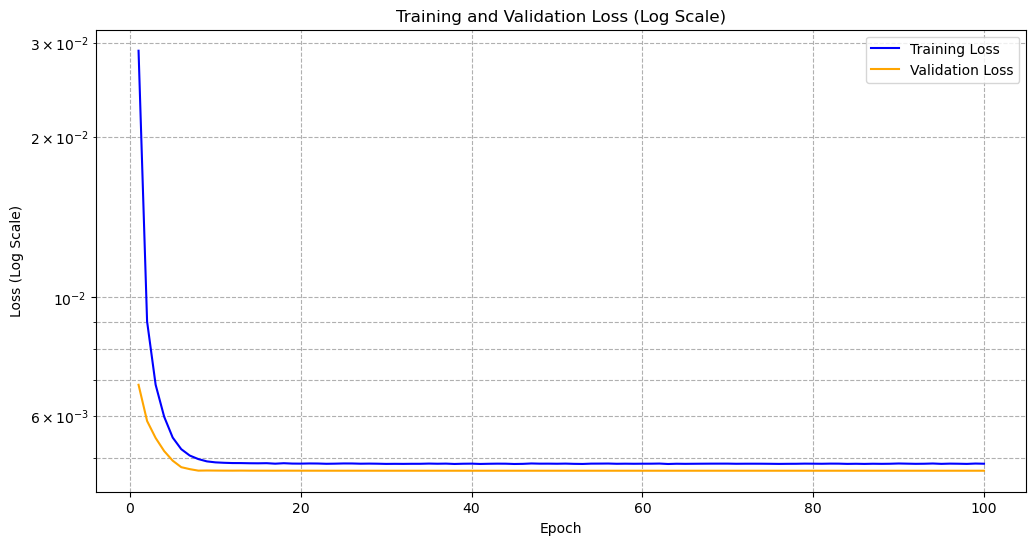

GCNModel(
  (conv1): GCNConv(4, 16)
  (conv2): GCNConv(16, 32)
  (conv3): GCNConv(32, 16)
  (fc): Linear(in_features=16, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [3]:
import os
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error

# データフォルダ
standardized_data_folder = "/home/nishioka/GNN/Defect_4x4_Normalized1"
label_data_folder = "/home/nishioka/GNN/Defectlabel4x4/DefectLabels_4x4_test1"

# 座標データのロード
x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]

# エッジ情報を読み込む
edges = np.load("/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy")
edge_index = torch.tensor(edges.T, dtype=torch.long)

# データとラベルのペアを取得する関数
def extract_layer_block(file_name):
    if file_name.startswith("0"):
        return (0, 0)  # 欠陥なしデータの場合
    try:
        layer_block_str = file_name.split("_")[-1].replace(".npy", "")
        layer_str = layer_block_str.split("L")[1].split("B")[0]
        block_str = layer_block_str.split("B")[1]
        layer = int(layer_str)
        block = int(block_str)
        return (layer, block)
    except (ValueError, IndexError):
        print(f"無効なファイル名の形式: {file_name}")
        return None
        
# データとラベルファイルを対応付け
data_files = [f for f in os.listdir(standardized_data_folder) if f.startswith("Normalized1_Defect4x4_ELNOD")]
label_files = [f for f in os.listdir(label_data_folder) if f.startswith("DefectLabel_L")]

# 欠陥なしデータのペア
defect_free_pair = ("/home/nishioka/GNN/BasicdataforGNN/Normalized1_nodefect_ElNOD.npy",
                    "/home/nishioka/GNN/BasicdataforGNN/DefectLabel_nodefect.npy")

# 初期のペアリスト
train_pairs = []
val_pairs = []
test_pairs = []

# 欠陥なしデータを追加
for _ in range(8):
 train_pairs.append(defect_free_pair)
val_pairs.append(defect_free_pair)
test_pairs.append(defect_free_pair)

# ペアのデータをカウントして確認
def count_pair_occurrences(pairs, target_pair):
    return pairs.count(target_pair)

train_count = count_pair_occurrences(train_pairs, defect_free_pair)
val_count = count_pair_occurrences(val_pairs, defect_free_pair)
test_count = count_pair_occurrences(test_pairs, defect_free_pair)

print(f"\nDefect-free data occurrences in train_pairs: {train_count} (expected: 8)")
print(f"Defect-free data occurrences in val_pairs: {val_count} (expected: 1)")
print(f"Defect-free data occurrences in test_pairs: {test_count} (expected: 1)")

if train_count == 8 and val_count == 1 and test_count == 1:
    print("\nAll defect-free data pairs are correctly added.")
else:
    print("\nThere is an issue with adding defect-free data pairs.")

# データとラベルのペアを作成
data_label_pairs = {}
for data_file in data_files:
    layer_block = extract_layer_block(data_file)
    if layer_block:
        data_label_pairs[layer_block] = {"data": data_file}

for label_file in label_files:
    layer_block = extract_layer_block(label_file)
    if layer_block and layer_block in data_label_pairs:
        data_label_pairs[layer_block]["label"] = label_file

# 有効なペアのみ取得
valid_pairs = [(v["data"], v["label"]) for k, v in data_label_pairs.items() if "label" in v]

# ランダムに1200個のペアをサンプリング
num_samples = 1200
random_indices = np.random.choice(len(valid_pairs), num_samples, replace=False)

# トレーニングデータと残りのデータを分ける
train_pairs = [valid_pairs[i] for i in random_indices]
remaining_pairs = [valid_pairs[i] for i in range(len(valid_pairs)) if i not in random_indices]

# 残りのデータを1:1でバリデーションとテストに分割
val_pairs, test_pairs = train_test_split(remaining_pairs, test_size=0.5, random_state=42)

# データ準備の関数
def prepare_data(pairs):
    sampled_data = []
    sampled_labels = []
    
    for data_file, label_file in pairs:
        data_file_path = os.path.join(standardized_data_folder, data_file)
        label_file_path = os.path.join(label_data_folder, label_file)

        # データとラベルを読み込む
        values = np.load(data_file_path)[:3654]
        label = np.load(label_file_path)[:3654]
        
        # 座標データと応力データを結合してノード特徴量を作成
        node_features = np.vstack((x_coords, y_coords, z_coords, values)).T
        sampled_data.append(node_features)
        sampled_labels.append(label)
    
    # データを結合しテンソルに変換
    sampled_data = np.stack(sampled_data)
    sampled_labels = np.hstack(sampled_labels)

    x = torch.tensor(sampled_data.reshape(-1, 4), dtype=torch.float)
    y = torch.tensor(sampled_labels, dtype=torch.float)  # 回帰のため

    return x, y

# 各データセットを準備
train_x, train_y = prepare_data(train_pairs)
val_x, val_y = prepare_data(val_pairs)
test_x, test_y = prepare_data(test_pairs)

# Dataオブジェクトにまとめる
train_data = Data(x=train_x, edge_index=edge_index, y=train_y)
val_data = Data(x=val_x, edge_index=edge_index, y=val_y)
test_data = Data(x=test_x, edge_index=edge_index, y=test_y)

print(f"Training data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")
print(f"Test data size: {len(test_data)}")

# 欠陥なしデータがトレーニングデータに含まれているか確認
no_defect_in_train = ("0Standardized1_nodefect_4x4_ElNOD.npy", "0DefectLabel_nodefect1.npy") in train_pairs

if no_defect_in_train:
    print("Defect-free data is included in the training data.")
else:
    print("欠陥なしデータがトレーニングデータに含まれていません。")

# 結果を確認
print(f"Training data: {train_data}")
print(f"Validation data: {val_data}")
print(f"Test data: {test_data}")

# ペアが正しく対応しているか確認
print("\n--- Training ---")
for data_file, label_file in train_pairs[:2]:  # トレーニングデータの先頭3個を表示
    print(f"data: {data_file}, label: {label_file}")

print("\n--- Validation ---")
for data_file, label_file in val_pairs[:2]:  # 検証データの先頭3個を表示
    print(f"data: {data_file}, label: {label_file}")

print("\n--- Test ---")
for data_file, label_file in test_pairs[:2]:  # テストデータの先頭3個を表示
    print(f"data: {data_file}, label: {label_file}")

# GCNモデル
class GCNModel(torch.nn.Module):
    def __init__(self):
        super(GCNModel, self).__init__()
        self.conv1 = GCNConv(4, 16)
        self.conv2 = GCNConv(16, 32)
        self.conv3 = GCNConv(32, 16)
        self.fc = torch.nn.Linear(16, 1)  # 回帰タスクのため出力は1次元
        self.dropout = torch.nn.Dropout(p=0.5)  # ドロップアウト

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.fc(x)

# モデル、損失関数、オプティマイザの定義
model = GCNModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0005)  # L2正則化
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)  # 学習率スケジューリング
loss_fn = torch.nn.MSELoss()

# データをサンプルごとに分割
train_data_list = []
val_data_list = []
test_data_list = []

num_train_samples = train_x.shape[0] // 3654
num_val_samples = val_x.shape[0] // 3654
num_test_samples = test_x.shape[0] // 3654

for i in range(num_train_samples):
    train_data_list.append(Data(x=train_x[i*3654:(i+1)*3654], edge_index=edge_index, y=train_y[i*3654:(i+1)*3654]))

for i in range(num_val_samples):
    val_data_list.append(Data(x=val_x[i*3654:(i+1)*3654], edge_index=edge_index, y=val_y[i*3654:(i+1)*3654]))

for i in range(num_test_samples):
    test_data_list.append(Data(x=test_x[i*3654:(i+1)*3654], edge_index=edge_index, y=test_y[i*3654:(i+1)*3654]))

# データローダーの作成
train_loader = DataLoader(train_data_list, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data_list, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data_list, batch_size=32, shuffle=False)

# バッチの形状を確認
for batch in train_loader:
    print(f"Train batch X shape: {batch.x.shape}")
    print(f"Train batch Y shape: {batch.y.shape}")
    break

for batch in val_loader:
    print(f"Validation batch X shape: {batch.x.shape}")
    print(f"Validation batch Y shape: {batch.y.shape}")
    break

for batch in test_loader:
    print(f"Test batch X shape: {batch.x.shape}")
    print(f"Test batch Y shape: {batch.y.shape}")
    break

# 学習と検証
train_losses = []
val_losses = []
test_losses = []

for epoch in range(1, 101):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.view(-1, 1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    train_losses.append(total_loss / len(train_loader))

    # 検証
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            out = model(batch)
            loss = loss_fn(out, batch.y.view(-1, 1))
            val_loss += loss.item()
    
    val_losses.append(val_loss / len(val_loader))
    scheduler.step()  # 学習率を調整
    print(f'Epoch {epoch}, Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}')

# テストデータでの評価
test_loss = 0
test_preds = []
test_targets = []
with torch.no_grad():
    for batch in test_loader:
        out = model(batch)
        loss = loss_fn(out, batch.y.view(-1, 1))
        test_loss += loss.item()
        test_preds.append(out.cpu().numpy())
        test_targets.append(batch.y.cpu().numpy())

test_loss /= len(test_loader)
test_preds = np.concatenate(test_preds)
test_targets = np.concatenate(test_targets)
rmse = np.sqrt(mean_squared_error(test_targets, test_preds))

print(f'Test Loss: {test_loss:.4f}, RMSE: {rmse:.4f}')

# 損失をプロット
plt.figure(figsize=(12, 6))
plt.plot(range(1, 101), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, 101), val_losses, label='Validation Loss', color='orange')
plt.yscale('log')  # 対数スケール
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title('Training and Validation Loss (Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# 損失をCSVに保存
loss_data = pd.DataFrame({
    'Epoch': range(1, 101),
    'Training Loss': train_losses,
    'Validation Loss': val_losses
})
loss_data.to_csv('loss_data.csv', index=False)

test_loss_data = pd.DataFrame({
    'Test Loss': [test_loss],
    'RMSE': [rmse]
})
test_loss_data.to_csv('test_loss.csv', index=False)

# モデルの保存
torch.save(model.state_dict(), 'gcn_model.pth')

# 保存したパラメータを読み込む
model.load_state_dict(torch.load('gcn_model.pth'))

print(model)


In [4]:
print("Test Targets:", test_targets[:20])
print("Test Predictions:", test_preds[:20])

Test Targets: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Test Predictions: [[0.00280336]
 [0.00585715]
 [0.00111338]
 [0.00236285]
 [0.0031555 ]
 [0.00324269]
 [0.00331599]
 [0.00338031]
 [0.00343382]
 [0.00347671]
 [0.00351867]
 [0.00356016]
 [0.00365192]
 [0.00380239]
 [0.00392222]
 [0.00404468]
 [0.00419205]
 [0.00444445]
 [0.00477982]
 [0.00511569]]
